# **Exercise 1 : Question 1,3,4 (2 and 5 are not mandatory [R]**

# Question 1

alpha0=    1 | x*=[-49.  36.] | g(x*)=0.00e+00 | iterations=1
alpha0=  0.9 | x*=[-49.  36.] | g(x*)=2.63e-22 | iterations=13
alpha0= 0.75 | x*=[-49.  36.] | g(x*)=1.36e-21 | iterations=21
alpha0=  0.6 | x*=[-49.  36.] | g(x*)=8.95e-22 | iterations=32
alpha0=  0.5 | x*=[-49.  36.] | g(x*)=0.00e+00 | iterations=1
alpha0=  0.4 | x*=[-49.  36.] | g(x*)=1.81e-21 | iterations=18
alpha0= 0.25 | x*=[-49.  36.] | g(x*)=1.36e-21 | iterations=42
alpha0=  0.1 | x*=[-49.  36.] | g(x*)=1.67e-21 | iterations=130
alpha0= 0.01 | x*=[-49.  36.] | g(x*)=2.49e-21 | iterations=1426


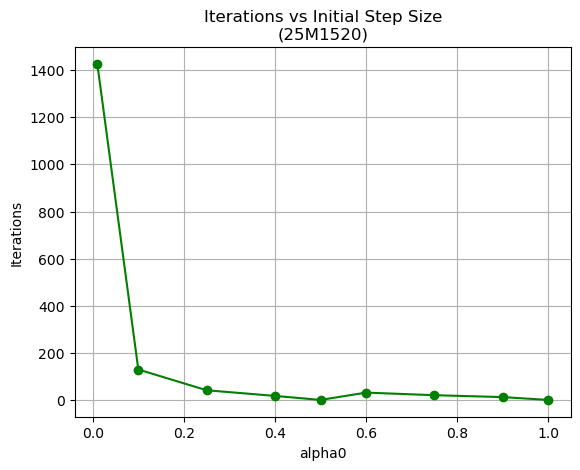

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Objective Function and Gradient
def g(x):
    return (x[0] + 49)**2 + (x[1] - 36)**2

def grad_g(x):
    return np.array([2*(x[0] + 49), 2*(x[1] - 36)])

# Backtracking Line Search
def backtracking(x, p, alpha0, rho=0.5, gamma=0.5):
    alpha = alpha0
    while g(x + alpha*p) > g(x) + gamma*alpha*np.dot(grad_g(x), p):
        alpha *= rho
    return alpha

# Gradient Descent with Backtracking
def gradient_descent_bt(x0, alpha0, tol=1e-10):
    x = x0.copy()
    path = [x.copy()]
    k = 0

    while np.linalg.norm(grad_g(x)) > tol:
        p = -grad_g(x)
        alpha = backtracking(x, p, alpha0)
        x = x + alpha * p
        path.append(x.copy())
        k += 1

    return x, g(x), k, np.array(path)

# --------------------------------------------------------------------------------------

# Experiment
alpha_vals = [1, 0.9, 0.75, 0.6, 0.5, 0.4, 0.25, 0.1, 0.01]
x0 = np.array([100., 100.])

results = []
for a in alpha_vals:
    xmin, fmin, iters, path = gradient_descent_bt(x0, a)
    results.append((a, xmin, fmin, iters))
    print(f"alpha0={a:>5} | x*={xmin} | g(x*)={fmin:.2e} | iterations={iters}")

# Plot: Iterations vs alpha0
iters = [r[3] for r in results]
plt.figure()
plt.plot(alpha_vals, iters, marker='o', linestyle='-', color='g')
plt.xlabel("alpha0")
plt.ylabel("Iterations")
plt.title("Iterations vs Initial Step Size\n(25M1520)")
plt.grid()
plt.show()

In [2]:
print("""Observations :
For all values of α0, the algorithm converges to the same minimizer x* = (-49,36)  g(x*)=0
However, the number of iterations depends on α0
    1. Larger values of α0 converges faster (fewer iterations)
    2. Smaller values of α0 takes more iterations to converge
""")
print("""Conclusion :
Choosing a larger initial step size α0 can lead to faster convergence in gradient descent with backtracking line search.
However, excessively large α0 may lead to instability, so a balance is needed.  
""")

Observations :
For all values of α0, the algorithm converges to the same minimizer x* = (-49,36)  g(x*)=0
However, the number of iterations depends on α0
    1. Larger values of α0 converges faster (fewer iterations)
    2. Smaller values of α0 takes more iterations to converge

Conclusion :
Choosing a larger initial step size α0 can lead to faster convergence in gradient descent with backtracking line search.
However, excessively large α0 may lead to instability, so a balance is needed.  



# Question 3

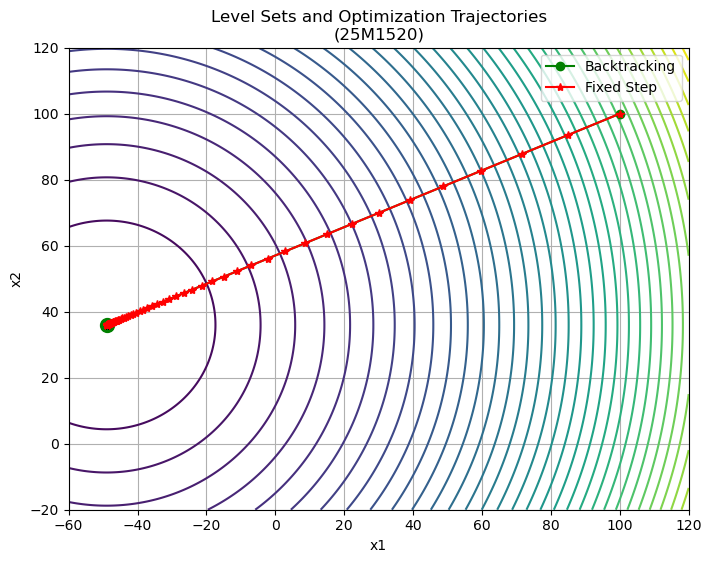

In [3]:
# Fixed Step Gradient Descent
def gradient_descent_fixed(x0, alpha, tol=1e-10):
    x = x0.copy()
    path = [x.copy()]
    k = 0

    while np.linalg.norm(grad_g(x)) > tol:
        x = x - alpha * grad_g(x)
        path.append(x.copy())
        k += 1

    return x, g(x), k, np.array(path)

# Generate both trajectories
x0 = np.array([100., 100.])

# Backtracking
xmin_bt, fmin_bt, it_bt, path_bt = gradient_descent_bt(x0, 1)

# Fixed step (chosen reasonably)
xmin_fx, fmin_fx, it_fx, path_fx = gradient_descent_fixed(x0, 0.05)

# Plot Level Sets + Both Trajectories
x1 = np.linspace(-60, 120, 300)
x2 = np.linspace(-20, 120, 300)
X, Y = np.meshgrid(x1, x2)
Z = (X + 49)**2 + (Y - 36)**2

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, 40)

# Backtracking trajectory
plt.plot(path_bt[:,0], path_bt[:,1], 'go-', label='Backtracking')

# Fixed step trajectory
plt.plot(path_fx[:,0], path_fx[:,1], 'r*-', label='Fixed Step')

# Mark minimizer
plt.scatter(-49, 36, c='green', s=100)

plt.legend()
plt.title("Level Sets and Optimization Trajectories\n(25M1520)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid()
plt.show()

In [4]:
print("""Observations :
The contour plot of g(x) together with both optimization trajectories reveals the following:
1. Backtracking Line Search
    a) Moves rapidly towards the minimizer initially, then fine-tunes as it approaches.
    b) Automatically adjusts step sizes, leading to efficient convergence.
    c) Requires fewer iterations compared to fixed step size method and follows a more direct path to the minimizer.

2. Fixed Step Size Gradient Descent
    a) Converges only when the step size is chosen carefully.
    b) Typically takes more iterations and a less direct path to the minimizer compared to backtracking.
    c) Either moves slowly (if step is small) or overshoots (if step is large), leading to inefficient convergence.

3. Comparison
    a) Backtracking exhibits faster and more reliable convergence due to adaptive step sizing.
    b) Fixed step size method is sensitive to the choice of step size and may require trial-and-error to find an optimal value.
    c) The backtracking method generally outperforms the fixed step size method in terms of convergence speed and path efficiency.
""")
print("""Conclusion :
The experiment demonstrates the advantages of backtracking line search over fixed step size gradient descent in terms of convergence speed and reliability.
""")

Observations :
The contour plot of g(x) together with both optimization trajectories reveals the following:
1. Backtracking Line Search
    a) Moves rapidly towards the minimizer initially, then fine-tunes as it approaches.
    b) Automatically adjusts step sizes, leading to efficient convergence.
    c) Requires fewer iterations compared to fixed step size method and follows a more direct path to the minimizer.

2. Fixed Step Size Gradient Descent
    a) Converges only when the step size is chosen carefully.
    b) Typically takes more iterations and a less direct path to the minimizer compared to backtracking.
    c) Either moves slowly (if step is small) or overshoots (if step is large), leading to inefficient convergence.

3. Comparison
    a) Backtracking exhibits faster and more reliable convergence due to adaptive step sizing.
    b) Fixed step size method is sensitive to the choice of step size and may require trial-and-error to find an optimal value.
    c) The backtracking me

# Question 4

# Max Iterations set to 5 Lakhs 
# starting point changed to (0,0) instead of (100,100) as (2,4) is the minimum point

alpha0=    1 | x*=[2. 4.] | f(x*)=4.16e-20 | iterations=152302
alpha0=  0.9 | x*=[2. 4.] | f(x*)=4.21e-20 | iterations=73704

Reached maximum iterations for 0.75
alpha0= 0.75 | x*=[2. 4.] | f(x*)=1.33e-19 | iterations=500000
alpha0=  0.6 | x*=[2. 4.] | f(x*)=4.03e-20 | iterations=407047
alpha0=  0.5 | x*=[2. 4.] | f(x*)=4.17e-20 | iterations=152724
alpha0=  0.4 | x*=[2. 4.] | f(x*)=4.10e-20 | iterations=348974
alpha0= 0.25 | x*=[2. 4.] | f(x*)=4.17e-20 | iterations=152909
alpha0=  0.1 | x*=[2. 4.] | f(x*)=4.10e-20 | iterations=348861

Reached maximum iterations for 0.01
alpha0= 0.01 | x*=[2. 4.] | f(x*)=2.41e-19 | iterations=500000


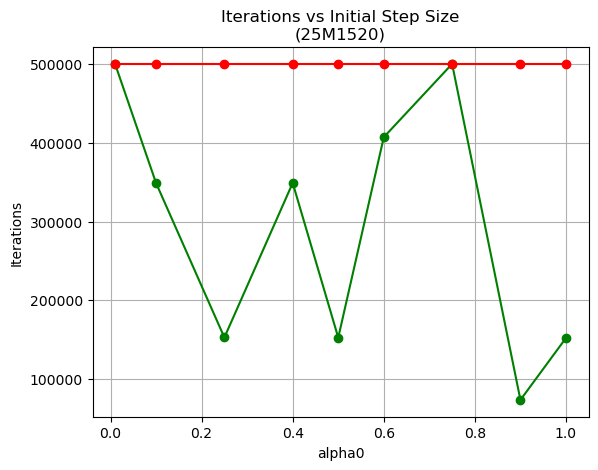

In [5]:
# New function for Question 4
def f(x):
    return 256*(x[1] - x[0]**2)**2 + (2 - x[0])**2

def grad_f(x):
    return np.array([
        -1024*x[0]*(x[1] - x[0]**2) - 2*(2 - x[0]),
        512*(x[1] - x[0]**2)
    ])

# Backtracking Line Search
def backtracking_f(x, p, alpha0, rho=0.5, gamma=0.5):
    alpha = alpha0
    while f(x + alpha*p) > f(x) + gamma*alpha*np.dot(grad_f(x), p):
        alpha *= rho
    return alpha

# Gradient Descent with Backtracking
def gradient_descent_bt_f(x0, alpha0, tol=1e-10, max_iterations=500000):
    x = x0.copy()
    path = [x.copy()]
    k = 0

    while np.linalg.norm(grad_f(x)) > tol and k < max_iterations:
        p = -grad_f(x)
        alpha = backtracking_f(x, p, alpha0)
        x = x + alpha * p
        path.append(x.copy())
        k += 1
        if k == max_iterations:
            print(f"\nReached maximum iterations for {alpha0}")

    return x, f(x), k, np.array(path)

# --------------------------------------------------------------------------------------

# Experiment
alpha_vals = [1, 0.9, 0.75, 0.6, 0.5, 0.4, 0.25, 0.1, 0.01]
x0 = np.array([0.0, 0.0])

results = []
for a in alpha_vals:
    xmin, fmin, iters, path = gradient_descent_bt_f(x0, a)
    results.append((a, xmin, fmin, iters))
    print(f"alpha0={a:>5} | x*={xmin} | f(x*)={fmin:.2e} | iterations={iters}")

# Plot: Iterations vs alpha0
iters = [r[3] for r in results]
plt.figure()
plt.plot(alpha_vals, iters, marker='o', linestyle='-', color='g')
plt.plot(alpha_vals, [500000]*len(alpha_vals), marker='o', linestyle='-', color='r')
plt.xlabel("alpha0")
plt.ylabel("Iterations")
plt.title("Iterations vs Initial Step Size\n(25M1520)")
plt.grid()
plt.show()

# **Exercise 2 : Question 2,3,4 (1 is not mandatory [R]**

 n | BFGS time | BFGS minimizer (first 5, last) | f(x*) | SD time | SD minimizer (first 5, last) | f(x*)
------------------------------------------------------------------------------------------------------------------------
 1000 |    3.4019 | [1. 1. 1. 1. 1.] ... 1.0000         | 1.68e-14 |  4.0651 | [1. 1. 1. 1. 1.] ... 1.0000         | 8.02e-13
 2500 |   14.4548 | [1. 1. 1. 1. 1.] ... 1.0000         | 1.36e-14 | 10.5861 | [1. 1. 1. 1. 1.] ... 1.0000         | 8.62e-13
 5000 |   45.4897 | [1. 1. 1. 1. 1.] ... 1.0000         | 7.75e-15 | 21.4052 | [1. 1. 1. 1. 1.] ... 1.0000         | 7.55e-13
 7500 |   90.9950 | [1. 1. 1. 1. 1.] ... 1.0000         | 1.15e-14 | 31.9757 | [1. 1. 1. 1. 1.] ... 1.0000         | 7.55e-13
10000 |  111.6774 | [1. 1. 1. 1. 1.] ... 1.0000         | 1.28e-14 | 39.2935 | [1. 1. 1. 1. 1.] ... 1.0000         | 8.17e-13


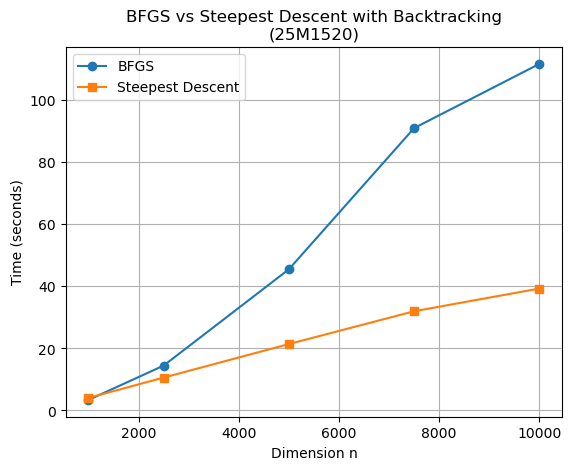

In [7]:
import time

def f(x):
    n = len(x)
    val = 0.0
    for i in range(n-1):
        val += 4*(x[i]**2 - x[i+1])**2 + (x[i] - 1)**2
    return val

def grad_f(x):
    n = len(x)
    g = np.zeros(n)

    for i in range(n-1):
        g[i] += 16*x[i]*(x[i]**2 - x[i+1]) + 2*(x[i] - 1)
        g[i+1] += -8*(x[i]**2 - x[i+1])

    return g

def backtracking(x, p, alpha0=0.9, rho=0.5, gamma=0.5):
    alpha = alpha0
    fx = f(x)
    gxp = np.dot(grad_f(x), p)

    while f(x + alpha*p) > fx + gamma*alpha*gxp:
        alpha *= rho
        if alpha < 1e-12:
            break
    return alpha

def bfgs(n, tol=1e-6, max_iter=2000):
    x = np.zeros(n)
    B = np.eye(n)
    k = 0

    start = time.time()

    while np.linalg.norm(grad_f(x)) > tol and k < max_iter:
        g = grad_f(x)
        p = -B @ g
        alpha = backtracking(x, p)
        x_new = x + alpha*p

        s = x_new - x
        y = grad_f(x_new) - g
        ys = np.dot(y, s)

        if ys > 1e-12:
            Bs = B @ y
            B += np.outer(s, s)/ys - np.outer(Bs, Bs)/np.dot(y, Bs)

        x = x_new
        k += 1

    return x, time.time() - start

def steepest_descent(n, tol=1e-6, max_iter=200000):
    x = np.zeros(n)
    k = 0

    start = time.time()

    while np.linalg.norm(grad_f(x)) > tol and k < max_iter:
        p = -grad_f(x)
        alpha = backtracking(x, p)
        x = x + alpha*p
        k += 1

    return x, time.time() - start

ns = [1000, 2500, 5000, 7500, 10000]

bfgs_times = []
sd_times = []

print(" n | BFGS time | BFGS minimizer (first 5, last) | f(x*) | "
      "SD time | SD minimizer (first 5, last) | f(x*)")
print("-"*120)

for n in ns:
    x_bfgs, t_bfgs = bfgs(n)
    x_sd, t_sd = steepest_descent(n)

    bfgs_times.append(t_bfgs)
    sd_times.append(t_sd)

    # Function values
    f_bfgs = f(x_bfgs)
    f_sd = f(x_sd)

    # Minimizer snapshots
    bfgs_min_str = f"{x_bfgs[:5]} ... {x_bfgs[-1]:.4f}"
    sd_min_str   = f"{x_sd[:5]} ... {x_sd[-1]:.4f}"

    print(f"{n:5} | {t_bfgs:9.4f} | {bfgs_min_str:35} | {f_bfgs:8.2e} | "
          f"{t_sd:7.4f} | {sd_min_str:35} | {f_sd:8.2e}")

plt.figure()
plt.plot(ns, bfgs_times, 'o-', label="BFGS")
plt.plot(ns, sd_times, 's-', label="Steepest Descent")
plt.xlabel("Dimension n")
plt.ylabel("Time (seconds)")
plt.title("BFGS vs Steepest Descent with Backtracking\n(25M1520)")
plt.legend()
plt.grid(True)
plt.show()